## SUPPORT VECTOR MACHINE Assignment_10

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Task 1: Exploratory Data Analysis (EDA)
##### 1.	Load the dataset and perform fundamental data exploration.

In [16]:
#Load dataset
data = pd.read_csv('Pharma_Industry.csv')
data.head()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
0,-0.128538,0.303280,-1.881849,0.258286,-0.792011,1
1,-1.846188,2.865142,-0.929511,2.866786,-0.719447,1
2,-1.252393,-1.541613,0.363632,-0.325370,0.191314,0
3,1.992515,-1.142779,-0.766657,0.975286,-0.823355,1
4,0.377100,0.538410,-0.029263,1.896015,-0.960130,1


In [45]:
#shape
data.shape

(500, 6)

In [17]:
#check any missing value
data.isnull().sum()

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64

In [18]:
#data information and type
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB


In [43]:
#describe stats data
data.describe()

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,-0.037761,0.214957,0.062871,0.054398,-0.171863,0.5200
std,0.979891,1.247567,0.971978,0.986001,0.983765,0.5001
min,-3.019512,-3.773897,-2.940389,-3.401277,-3.110431,0.0000
25%,-0.642003,-0.565168,-0.648157,-0.586085,-0.797715,0.0000
50%,-0.019340,0.201532,0.027732,-0.065661,-0.108106,1.0000
75%,0.641151,0.951375,0.710774,0.633914,0.513555,1.0000
max,2.949094,4.111751,3.193108,3.373269,2.518023,1.0000


#### 2.	Utilize histograms, box plots, or density plots to understand feature distributions.

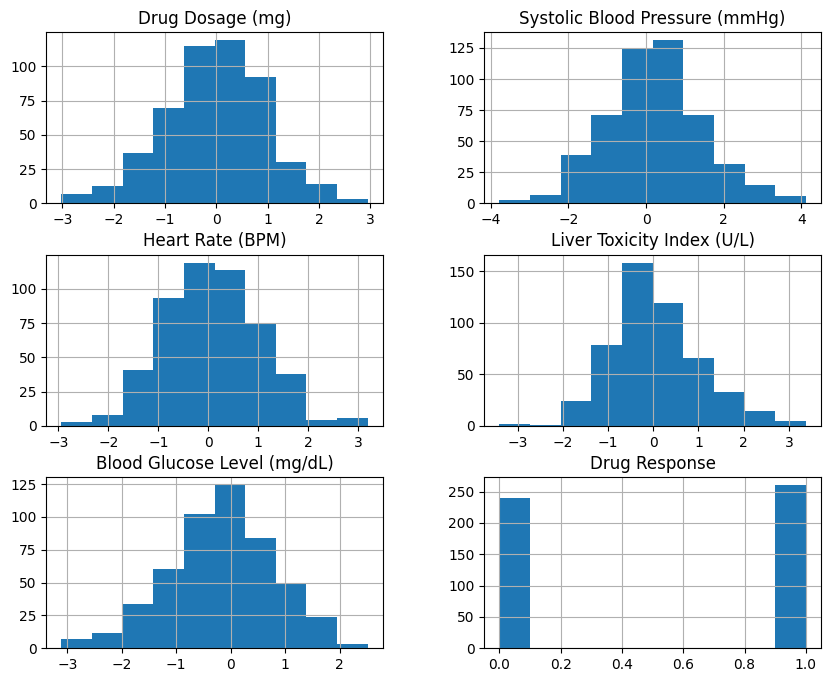

In [19]:
# Histograms
data.hist(figsize=(10,8))
plt.show()

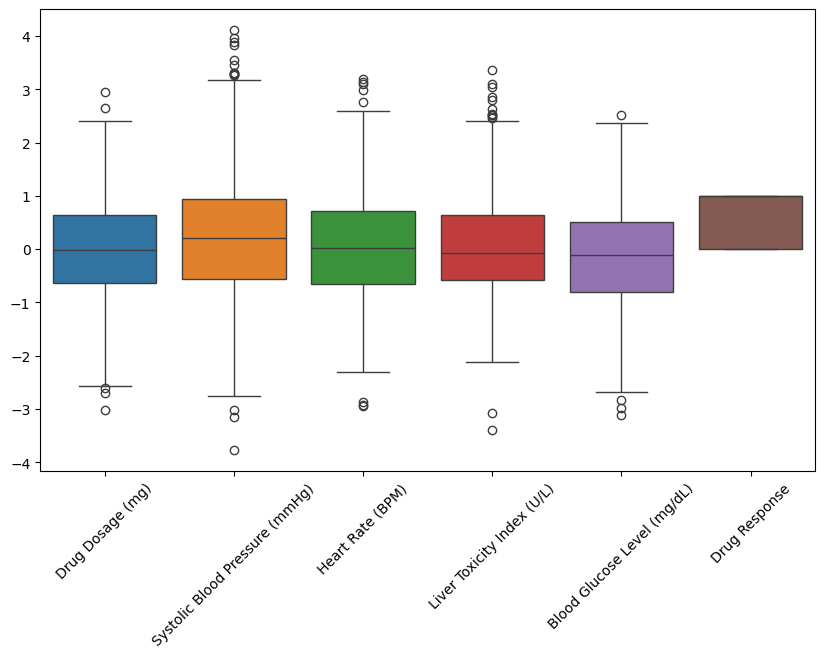

In [20]:
# Boxplots
plt.figure(figsize=(10,6))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.show()

#### 3.	Investigate feature correlations to discern relationships within the data.

In [21]:
corr=data.corr()
corr

,Drug Dosage (mg),Systolic Blood Pressure (mmHg),Heart Rate (BPM),Liver Toxicity Index (U/L),Blood Glucose Level (mg/dL),Drug Response
Drug Dosage (mg),1.000000,0.090618,0.040571,0.128127,0.012434,0.043457
Systolic Blood Pressure (mmHg),0.090618,1.000000,-0.039195,0.283672,0.037228,0.305226
Heart Rate (BPM),0.040571,-0.039195,1.000000,0.005818,0.049897,-0.009715
Liver Toxicity Index (U/L),0.128127,0.283672,0.005818,1.000000,0.229474,0.434722
Blood Glucose Level (mg/dL),0.012434,0.037228,0.049897,0.229474,1.000000,0.169342
Drug Response,0.043457,0.305226,-0.009715,0.434722,0.169342,1.000000


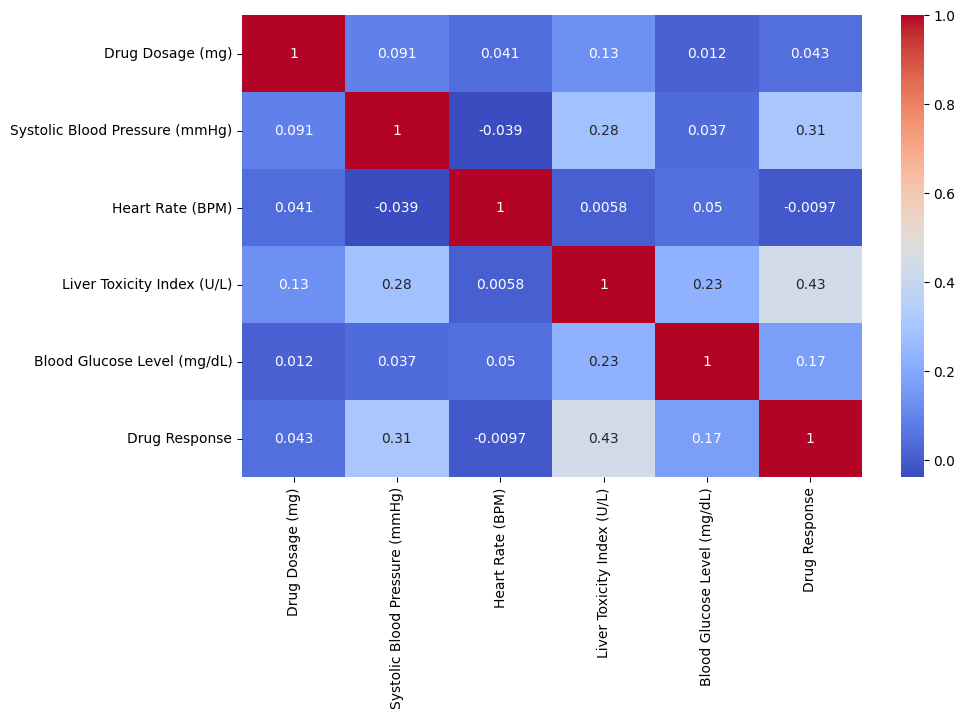

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

#### Task 2: Data Preprocessing

##### 1.	Encode categorical variables if necessary.

In [23]:
data.dtypes

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object

###### The dataset contains only numerical features, so no categorical encoding was required. All features were already in a suitable format for machine learning.

#### 2.	Split the dataset into training and testing sets.

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
#drop a Target dataset 
X = data.drop('Drug Response', axis=1)
#drug Response is Target
y = data['Drug Response']

In [26]:
#Split train and Test
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.2)
X_train.shape,X_test.shape, y_train.shape,y_test.shape

((400, 5), (100, 5), (400,), (100,))

###### The dataset was split into training and testing sets (80:20) to evaluate model performance.

### Task 3: Data Visualization

#### 1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.

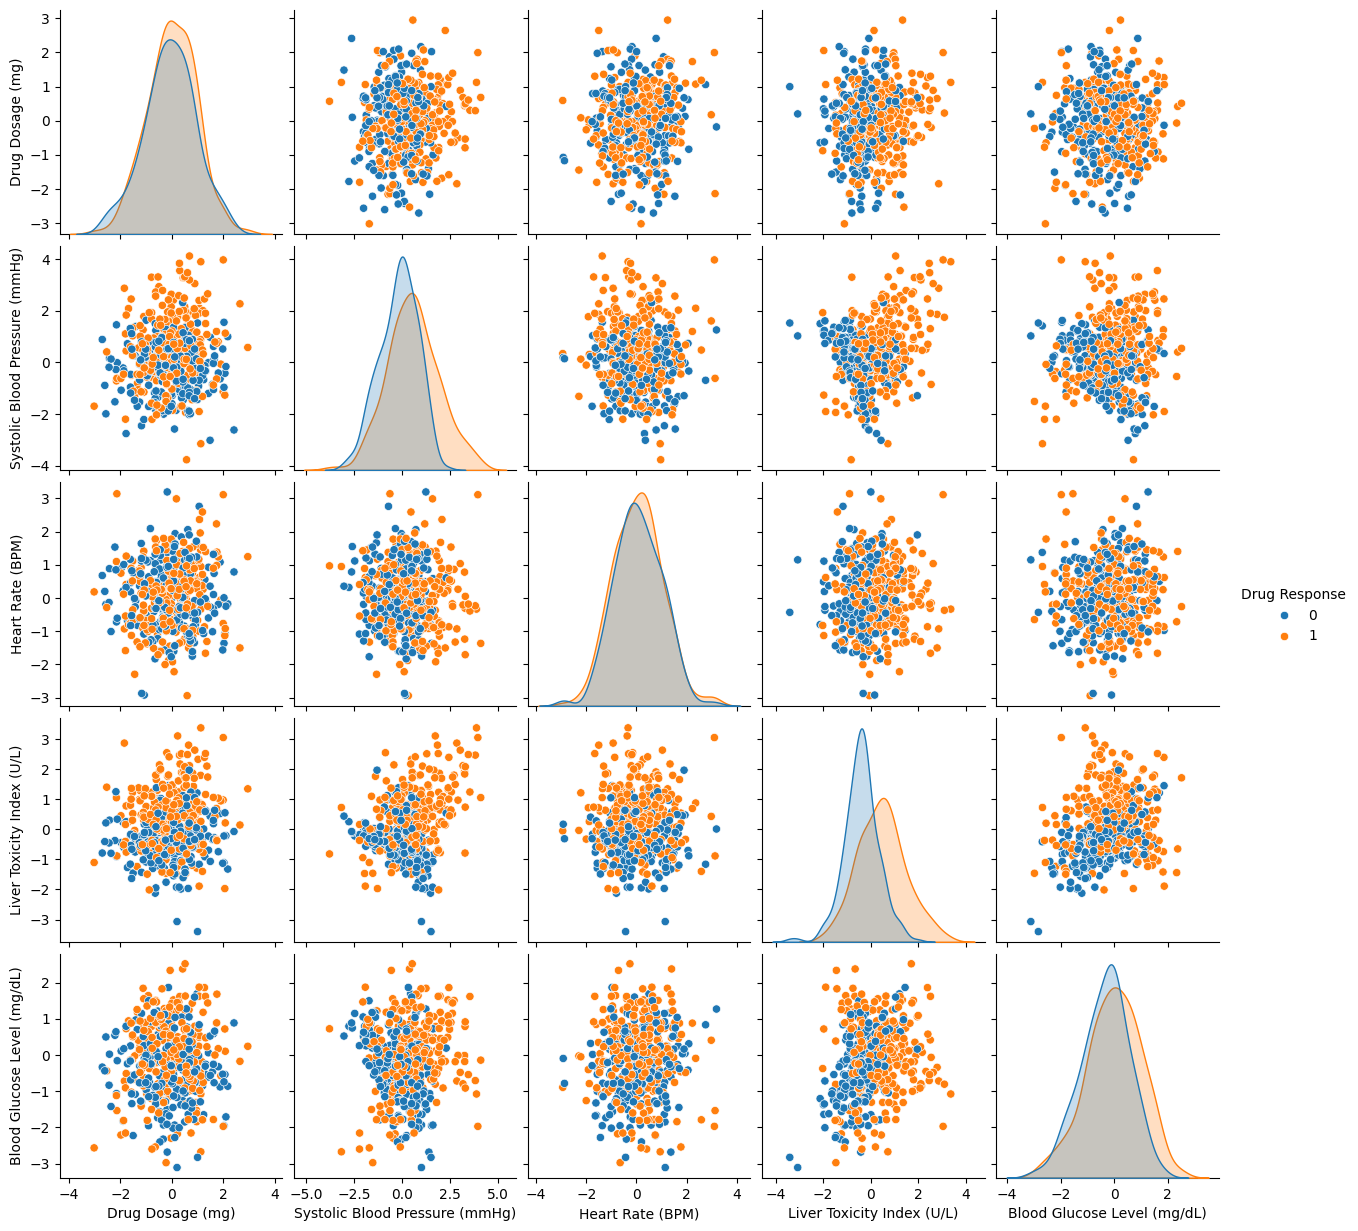

In [27]:
#Pair Plot
sns.pairplot(data, hue='Drug Response')
plt.show()

#### 2.	Visualize class distributions to gauge dataset balance or imbalance.

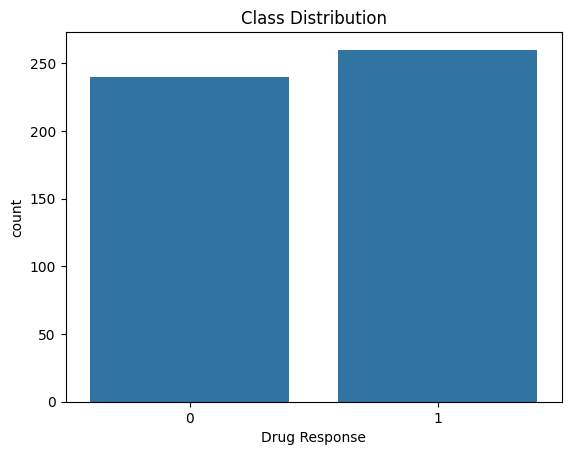

In [28]:
#CountPlot
sns.countplot(x='Drug Response', data=data)
plt.title("Class Distribution")
plt.show()

###### balanced distribution

### Task 4: SVM Implementation

#### 1.	Implement a basic SVM classifier using Python libraries like scikit-learn.

In [29]:
from sklearn.svm import SVC

In [30]:
#Build model
model = SVC(C=1.0, gamma=1.0)
model.fit(X_train,y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",1.0
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### 3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).

In [31]:
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score

###### Evaluate the model on training data

In [32]:
yhat_train = model.predict(X_train)
cm = confusion_matrix(y_train, yhat_train)
print("Confusion_matrix :", cm)

Confusion_matrix : [[175  13]
 [ 22 190]]


In [33]:
print(classification_report(y_train,yhat_train))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91       188
           1       0.94      0.90      0.92       212

    accuracy                           0.91       400
   macro avg       0.91      0.91      0.91       400
weighted avg       0.91      0.91      0.91       400



###### Evaluate the model on testing data

In [34]:
yhat_test = model.predict(X_test)
cm = confusion_matrix(y_test, yhat_test)
print("Confusion_matrix :", cm)

Confusion_matrix : [[35 17]
 [ 9 39]]


In [37]:
print(classification_report(y_test, yhat_test))

              precision    recall  f1-score   support

           0       0.80      0.67      0.73        52
           1       0.70      0.81      0.75        48

    accuracy                           0.74       100
   macro avg       0.75      0.74      0.74       100
weighted avg       0.75      0.74      0.74       100



### Task 5: Visualization of Results

#### 1.	Visualize classification results on the testing data.

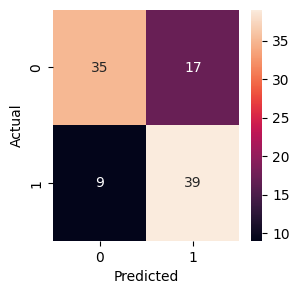

In [39]:
plt.figure(figsize=(3,3))
sns.heatmap(confusion_matrix(y_test, yhat_test), annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#### Task 6: Hyperparameter Tuning

#### 1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance


In [40]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

grid = GridSearchCV(SVC(), param_grid, cv=3)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


### Task 7: Comparison and Analysis

#### 1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).

In [42]:
kernels = ['linear', 'rbf', 'poly']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{k} Accuracy:", accuracy_score(y_test, y_pred))

linear Accuracy: 0.67
rbf Accuracy: 0.72
poly Accuracy: 0.71


#### 2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.


#### 3.	Discuss practical implications of SVM in real-world classification tasks.